# Upper Confidence Bound (UCB)

## Importing the libraries

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Importing the dataset

In [4]:
dataset = pd.read_csv('Ads_CTR_Optimisation.csv')

In [5]:
len(dataset)

10000

## Implementing UCB

In [25]:
N = 1000
d = 10 # number of ads
ads_selected = []
numbers_of_selections = [0]*d
sums_of_rewards = [0]* d
total_reward = 0

In [26]:
for n in range(0,N):
    ad = 0
    max_upper_bound = 0
    for i in range(0,d): 
        if numbers_of_selections[i] > 0 :
            empirical_mean = sums_of_rewards[i] / numbers_of_selections[i] 
            delta_i = np.sqrt(3/2 * (np.log(n+1)/numbers_of_selections[i]))
            upper_bound = empirical_mean + delta_i
        else :
           upper_bound = 1e400

       
        if upper_bound > max_upper_bound :
            max_upper_bound = upper_bound
            ad = i

    ads_selected.append(ad)
    numbers_of_selections[ad]+=1
    reward = dataset.values[n,ad]
    sums_of_rewards[ad]+= reward
    total_reward += dataset.values[n, ad]


## Visualising the results

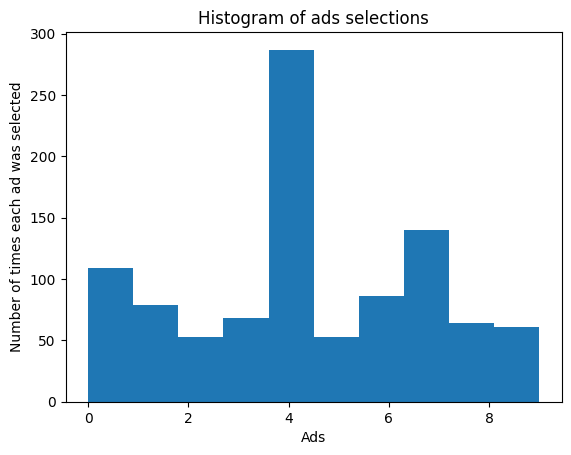

In [27]:
plt.hist(ads_selected)
plt.title('Histogram of ads selections')
plt.xlabel('Ads')
plt.ylabel('Number of times each ad was selected')
plt.show()